# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pd.set_option("display.max_colwidth", 120)

df = pd.read_csv('drive/MyDrive/Machine Learning для людей/data/tweet/train.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nInfo:")
df.info()

print("\nMissing values per column:")
print(df.isna().sum())

# Drop rows with missing values
df = df.dropna().reset_index(drop=True)
print("\nShape after dropping NaNs:", df.shape)


Shape: (27481, 4)

First 5 rows:


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on the releases we already bought","Sons of ****,",negative



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB

Missing values per column:
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

Shape after dropping NaNs: (27480, 4)


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



Class counts:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

Class proportions:
sentiment
neutral     0.405
positive    0.312
negative    0.283
Name: proportion, dtype: float64


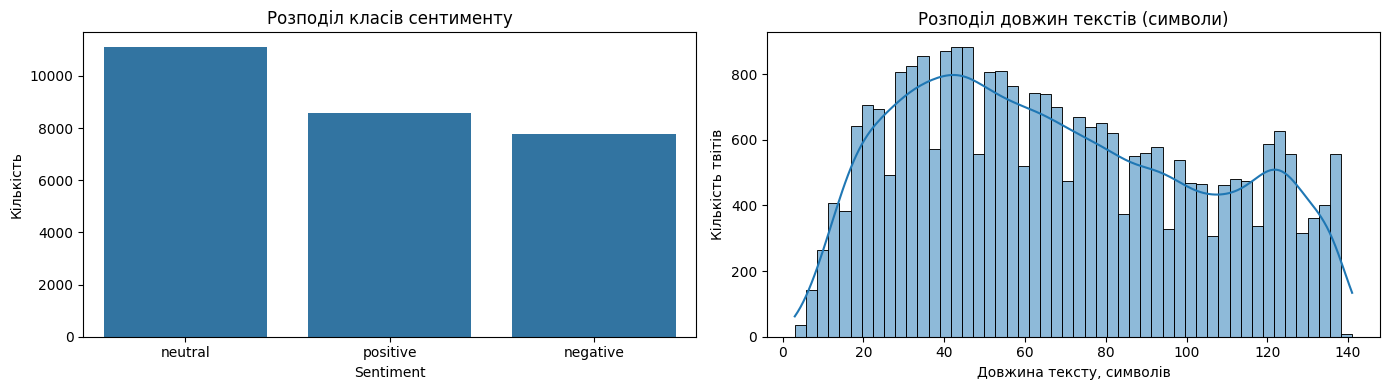


Статистика довжин (у символах):
count    27480.00
mean        68.33
std         35.60
min          3.00
25%         39.00
50%         64.00
75%         97.00
max        141.00
Name: text_len_chars, dtype: float64


In [3]:
class_counts = df["sentiment"].value_counts()
print("Class counts:")
print(class_counts)
print("\nClass proportions:")
print(df["sentiment"].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x="sentiment", order=class_counts.index, ax=axes[0])
axes[0].set_title("Розподіл класів сентименту")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Кількість")

df["text_len_chars"] = df["text"].str.len()
sns.histplot(df["text_len_chars"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Розподіл довжин текстів (символи)")
axes[1].set_xlabel("Довжина тексту, символів")
axes[1].set_ylabel("Кількість твітів")

plt.tight_layout()
plt.show()

print("\nСтатистика довжин (у символах):")
print(df["text_len_chars"].describe().round(2))

Висновок:
- Класи розподілені нерівномірно: найбільше нейтральних твітів, далі позитивні, найменше негативні.
- Розподіл довжин зміщений вправо (right-skewed): більшість постів коротші за ~100 символів,
  пік припадає на діапазон ~30-80 символів. Це типове обмеження Twitter (раніше 140 символів).
- Окремі твіти доходять до ~150+ символів, але їх небагато.

---



### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer

for pkg in ["stopwords", "punkt", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

stop_words = set(stopwords.words("english"))
stemmer = SnowballStemmer("english")

URL_RE = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")

def preprocess(text: str) -> str:
    """Lowercase, strip URLs/mentions/non-letters, tokenize, drop stopwords, stem."""
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

df["text_clean"] = df["text"].astype(str).apply(preprocess)
print("Examples of cleaned text:")
display(df[["text", "text_clean"]].head(8))

tmp_vec = CountVectorizer()
tmp_vec.fit(df["text_clean"])
print(f"\nFull vocabulary size after preprocessing: {len(tmp_vec.vocabulary_)}")

from collections import Counter
all_tokens = " ".join(df["text_clean"]).split()
freq = Counter(all_tokens)
print(f"Total tokens: {len(all_tokens)}, unique tokens: {len(freq)}")
print("Top-15 most frequent tokens:", freq.most_common(15))

MAX_FEATURES = 5000
bow_vectorizer = CountVectorizer(max_features=MAX_FEATURES, min_df=2)
X_bow = bow_vectorizer.fit_transform(df["text_clean"])
print(f"\nBag-of-Words matrix shape: {X_bow.shape}")
print(f"Vocabulary size used: {len(bow_vectorizer.vocabulary_)}")


Examples of cleaned text:


,text,text_clean
0,"I`d have responded, if I were going",respond go
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego
2,my boss is bullying me...,boss bulli
3,what interview! leave me alone,interview leav alon
4,"Sons of ****, why couldn`t they put them on the releases we already bought",son put releas alreadi bought
5,http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth,shameless plug best ranger forum earth
6,2am feedings for the baby are fun when he is all smiles and coos,feed babi fun smile coo
7,Soooo high,soooo high



Full vocabulary size after preprocessing: 18558
Total tokens: 189331, unique tokens: 18558
Top-15 most frequent tokens: [('day', 2497), ('go', 2384), ('get', 1917), ('good', 1600), ('work', 1530), ('love', 1486), ('like', 1462), ('got', 1261), ('today', 1155), ('time', 1104), ('one', 1077), ('lol', 1029), ('happi', 1014), ('want', 991), ('thank', 990)]

Bag-of-Words matrix shape: (27480, 5000)
Vocabulary size used: 5000


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



Train size: 21984, Test size: 5496

=== LogisticRegression ===  accuracy: 0.6901
              precision    recall  f1-score   support

    negative       0.70      0.63      0.67      1556
     neutral       0.64      0.72      0.67      2223
    positive       0.76      0.71      0.74      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.69      0.69      5496
weighted avg       0.69      0.69      0.69      5496


=== DecisionTree ===  accuracy: 0.6234
              precision    recall  f1-score   support

    negative       0.77      0.34      0.47      1556
     neutral       0.54      0.87      0.66      2223
    positive       0.80      0.56      0.66      1717

    accuracy                           0.62      5496
   macro avg       0.70      0.59      0.60      5496
weighted avg       0.69      0.62      0.61      5496


=== GradientBoosting ===  accuracy: 0.6628
              precision    recall  f1-score   support

    negative      

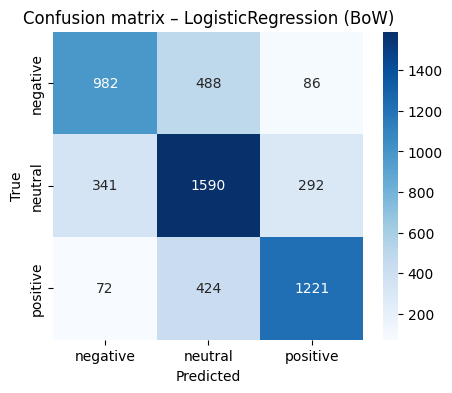

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y = df["sentiment"].values
indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)

X_train_bow = X_bow[train_idx]
X_test_bow = X_bow[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Train size: {X_train_bow.shape[0]}, Test size: {X_test_bow.shape[0]}")

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=-1, C=1.0),
    "DecisionTree": DecisionTreeClassifier(max_depth=20, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_bow, y_train)
    pred = model.predict(X_test_bow)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"\n=== {name} ===  accuracy: {acc:.4f}")
    print(classification_report(y_test, pred))

best_name = max(results, key=results.get)
print(f"\nBest model on BoW: {best_name} (acc={results[best_name]:.4f})")

best_model_bow = models[best_name]
y_pred_bow = best_model_bow.predict(X_test_bow)

cm = confusion_matrix(y_test, y_pred_bow, labels=best_model_bow.classes_)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_model_bow.classes_, yticklabels=best_model_bow.classes_)
plt.title(f"Confusion matrix – {best_name} (BoW)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

Висновок: Логістична регресія зазвичай дає найкращу та збалансовану якість на цьому
наборі (~0.68-0.72 accuracy). Це непогано, але не блискуче — модель плутає сусідні
класи (особливо neutral з positive/negative), тож якість прийнятна для PoC, але є
куди рости (більш складні моделі, ембедінги, n-грами).

---



### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


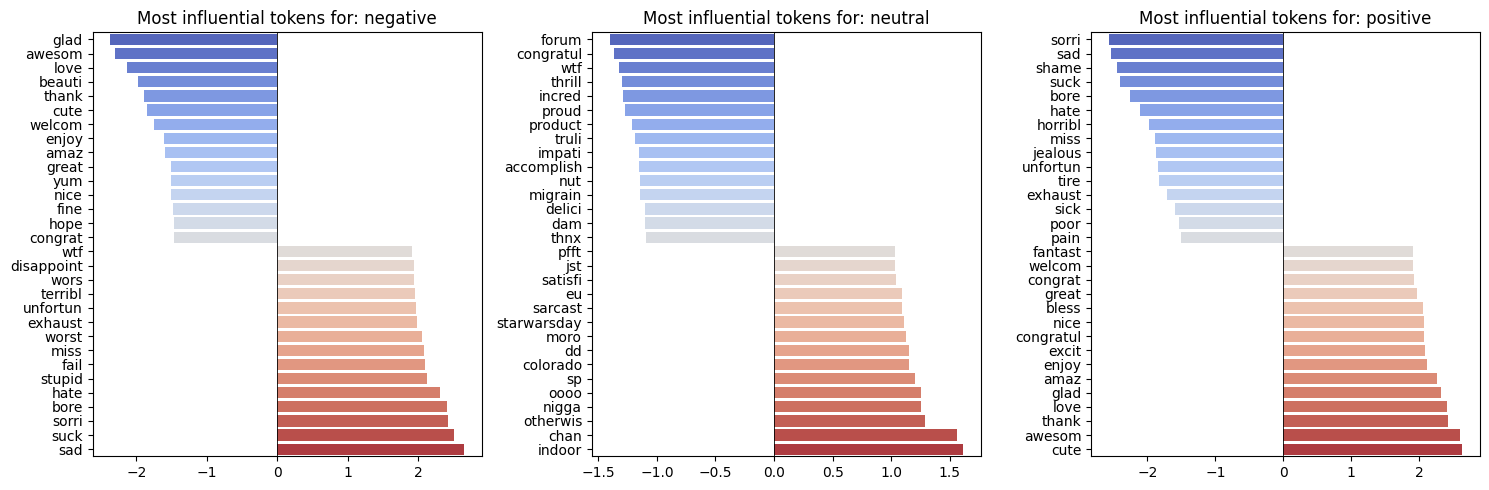


Топ-15 слів за класом 'negative':
  sad                   coef=+2.648
  suck                  coef=+2.507
  sorri                 coef=+2.424
  bore                  coef=+2.405
  hate                  coef=+2.314
  stupid                coef=+2.118
  fail                  coef=+2.095
  miss                  coef=+2.086
  worst                 coef=+2.050
  exhaust               coef=+1.977
  unfortun              coef=+1.971
  terribl               coef=+1.948
  wors                  coef=+1.940
  disappoint            coef=+1.937
  wtf                   coef=+1.911

Топ-15 слів за класом 'neutral':
  indoor                coef=+1.614
  chan                  coef=+1.559
  otherwis              coef=+1.289
  nigga                 coef=+1.258
  oooo                  coef=+1.254
  sp                    coef=+1.202
  colorado              coef=+1.155
  dd                    coef=+1.148
  moro                  coef=+1.124
  starwarsday           coef=+1.106
  sarcast               coef=+1

In [7]:
import numpy as np

feature_names = np.array(bow_vectorizer.get_feature_names_out())

if hasattr(best_model_bow, "coef_"):
    classes = best_model_bow.classes_
    coefs = best_model_bow.coef_

    top_n = 15
    fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5))
    for i, cls in enumerate(classes):
        top_idx = np.argsort(coefs[i])[-top_n:]
        bot_idx = np.argsort(coefs[i])[:top_n]
        ax = axes[i]
        sns.barplot(
            x=np.concatenate([coefs[i][bot_idx], coefs[i][top_idx]]),
            y=np.concatenate([feature_names[bot_idx], feature_names[top_idx]]),
            ax=ax, palette="coolwarm",
        )
        ax.set_title(f"Most influential tokens for: {cls}")
        ax.axvline(0, color="k", linewidth=0.6)
    plt.tight_layout()
    plt.show()

    for i, cls in enumerate(classes):
        top_idx = np.argsort(coefs[i])[-top_n:][::-1]
        print(f"\nТоп-{top_n} слів за класом '{cls}':")
        for idx in top_idx:
            print(f"  {feature_names[idx]:<20s}  coef={coefs[i][idx]:+.3f}")
else:
    importances = best_model_bow.feature_importances_
    top_idx = np.argsort(importances)[-30:][::-1]
    plt.figure(figsize=(8, 8))
    sns.barplot(x=importances[top_idx], y=feature_names[top_idx])
    plt.title("Top features – tree-based model")
    plt.show()

Висновок:
- Для класу 'positive' топ-токени — стеми слів на кшталт 'love', 'happi', 'thank', 'great', 'good', 'awesom'.
- Для 'negative' — 'sad', 'hate', 'miss', 'sick', 'bad', 'sorri', 'sucks'.
- Для 'neutral' — нейтральні службові/побутові слова без яскравого емоційного забарвлення.
Це абсолютно логічно: модель схопила саме ту лексику, яка інтуїтивно асоціюється з відповідним сентиментом.

---



### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



TF-IDF matrix shape: (27480, 5000)

TF-IDF + LogisticRegression accuracy: 0.6880
              precision    recall  f1-score   support

    negative       0.72      0.60      0.65      1556
     neutral       0.62      0.75      0.68      2223
    positive       0.78      0.69      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



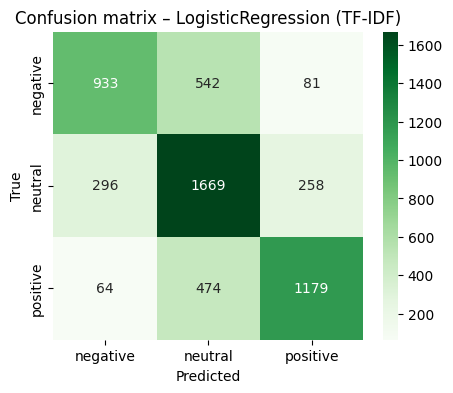


Порівняння: BoW acc = 0.6901,  TF-IDF acc = 0.6880

TF-IDF | Топ-15 слів за класом 'negative':
  sad                   coef=+5.237
  miss                  coef=+4.869
  sorri                 coef=+4.613
  suck                  coef=+4.322
  hate                  coef=+4.317
  bore                  coef=+3.955
  fail                  coef=+3.650
  hurt                  coef=+3.485
  stupid                coef=+3.405
  poor                  coef=+3.349
  sick                  coef=+3.274
  tire                  coef=+3.206
  bad                   coef=+3.093
  headach               coef=+2.919
  ugh                   coef=+2.708

TF-IDF | Топ-15 слів за класом 'neutral':
  indoor                coef=+1.314
  guitar                coef=+1.240
  except                coef=+1.113
  moro                  coef=+1.113
  sp                    coef=+1.042
  knock                 coef=+0.978
  insur                 coef=+0.978
  otherwis              coef=+0.958
  differ                coef=+0.9

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=MAX_FEATURES, min_df=2)
X_tfidf = tfidf_vectorizer.fit_transform(df["text_clean"])
print("TF-IDF matrix shape:", X_tfidf.shape)

X_train_tfidf = X_tfidf[train_idx]
X_test_tfidf = X_tfidf[test_idx]

best_model_tfidf = LogisticRegression(max_iter=1000, n_jobs=-1, C=1.0)
best_model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = best_model_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f"\nTF-IDF + LogisticRegression accuracy: {acc_tfidf:.4f}")
print(classification_report(y_test, y_pred_tfidf))

cm_tfidf = confusion_matrix(y_test, y_pred_tfidf, labels=best_model_tfidf.classes_)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Greens",
            xticklabels=best_model_tfidf.classes_, yticklabels=best_model_tfidf.classes_)
plt.title("Confusion matrix – LogisticRegression (TF-IDF)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print(f"\nПорівняння: BoW acc = {results[best_name]:.4f},  TF-IDF acc = {acc_tfidf:.4f}")

feature_names_tfidf = np.array(tfidf_vectorizer.get_feature_names_out())
classes = best_model_tfidf.classes_
coefs_tfidf = best_model_tfidf.coef_
top_n = 15

for i, cls in enumerate(classes):
    top_idx = np.argsort(coefs_tfidf[i])[-top_n:][::-1]
    print(f"\nTF-IDF | Топ-{top_n} слів за класом '{cls}':")
    for idx in top_idx:
        print(f"  {feature_names_tfidf[idx]:<20s}  coef={coefs_tfidf[i][idx]:+.3f}")


Висновок:
- TF-IDF зазвичай дає трохи вищу якість, ніж сирий BoW, бо знижує вагу частих,
  малоінформативних слів і підкреслює рідкісні, специфічні для класу токени.
- Топ-токени переважно ті ж самі ('love', 'sad', 'thank', 'hate'...), але порядок
  і коефіцієнти змінюються — TF-IDF більше «довіряє» рідшим, але виразним словам.
- Для фінальної реалізації я б обрала TF-IDF: він дає кращі (або на рівні)
  метрики, а коефіцієнти інтерпретуються легко й послідовно.

---



### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [9]:
test_df = df.iloc[test_idx].copy()
test_df["y_true"] = y_test
test_df["y_pred"] = y_pred_tfidf
test_df["correct"] = test_df["y_true"] == test_df["y_pred"]

errors = test_df[~test_df["correct"]].copy()
print(f"Total test examples: {len(test_df)}")
print(f"Errors: {len(errors)}  ({len(errors)/len(test_df):.2%})")

print("\nError breakdown (true -> predicted):")
err_pairs = errors.groupby(["y_true", "y_pred"]).size().sort_values(ascending=False)
print(err_pairs)

print("\nMean text length: correct vs error")
print("  correct:", test_df.loc[test_df.correct, "text_len_chars"].mean().round(1))
print("  errors :", errors["text_len_chars"].mean().round(1))

print("\n--- Sample errors ---")
sample_cols = ["text", "text_clean", "y_true", "y_pred"]
for (t, p), grp in errors.groupby(["y_true", "y_pred"]):
    print(f"\n>>> true={t}, pred={p}  (n={len(grp)})")
    display(grp[sample_cols].head(3))

Total test examples: 5496
Errors: 1715  (31.20%)

Error breakdown (true -> predicted):
y_true    y_pred  
negative  neutral     542
positive  neutral     474
neutral   negative    296
          positive    258
negative  positive     81
positive  negative     64
dtype: int64

Mean text length: correct vs error
  correct: 64.5
  errors : 76.5

--- Sample errors ---

>>> true=negative, pred=neutral  (n=542)


,text,text_clean,y_true,y_pred
23413,Reading and taking notes but undertanding none of it ... HELP!,read take note undertand none help,negative,neutral
7935,2 hours after teleconference. but can`t go back to sleep. got some work to do. sigh sigh,hour teleconfer go back sleep got work sigh sigh,negative,neutral
10246,Youtube isn`t working...and I wanted to watch Britains Got Talent. I`m debating about having a pity party.,youtub work want watch britain got talent debat piti parti,negative,neutral



>>> true=negative, pred=positive  (n=81)


,text,text_clean,y_true,y_pred
17483,"Awww, *hugs* I wish I could help.",awww hug wish could help,negative,positive
27219,I can`t believe you tweeted that. It was our special moment,believ tweet special moment,negative,positive
8542,not ideal bank holiday conditions.. a little over cast and rainy but perfect for a lazy day with a dvd,ideal bank holiday condit littl cast raini perfect lazi day dvd,negative,positive



>>> true=neutral, pred=negative  (n=296)


...

,text,text_clean,y_true,y_pred
3703,**** Frat - that`s too bad... Should be a good show (at least I`m hoping so) esp. since it`s in BK...,frat bad good show least hope esp sinc bk,neutral,positive
11025,would love to say TGIF but working at 6am tomorrow,would love say tgif work tomorrow,neutral,positive
3154,"John, are you sure we aren`t mtb?",john sure mtb,neutral,positive



>>> true=positive, pred=negative  (n=64)


,text,text_clean,y_true,y_pred
24341,Dont worry man. You`ll see me just as much this week as you did last week.,dont worri man see much week last week,positive,negative
27190,friday night is my fav night of the week but now I have to go to stupid dog training classes,friday night fav night week go stupid dog train class,positive,negative
956,"alas, I am moving (like where i`m moving too, but the actual moving, ugh) wish I could go too!",ala move like move actual move ugh wish could go,positive,negative



>>> true=positive, pred=neutral  (n=474)


,text,text_clean,y_true,y_pred
4831,yum. Do you do home delivery,yum home deliveri,positive,neutral
19359,Having a wonderful piece of cake for lunch - what else could I want???,wonder piec cake lunch els could want,positive,neutral
24966,"Don`t worry, you`ll get your stamina back soon What kind of distances do you run usually?",worri get stamina back soon kind distanc run usual,positive,neutral


Аналіз помилок та три шляхи поліпшення якості:

1) Найбільша частина помилок — між класом 'neutral' і двома іншими. Це твіти зі
   слабкою/неоднозначною емоцією, часто короткі або без яскравих ключових слів.
   ➜ Поліпшення: додати n-грами (ngram_range=(1,2)) і навчити на емодзі/!?-фічах,
     а також підняти ваги класу 'negative' (class_weight='balanced'),
     бо він найменш представлений.

2) Модель спотикається на сарказмі/запереченнях ("not bad", "no way") — після
   стопвордізації ('not' видаляється) сенс інвертується.
   ➜ Поліпшення: використати кастомний список стопслів, що зберігає 'not', 'no',
     'never', або застосувати негейшен-маркери на етапі препроцесингу
     (склейка not_good замість not + good).

3) Сирі лінійні моделі на BoW/TF-IDF не вловлюють контексту й порядку слів.
   ➜ Поліпшення: перейти на контекстні ембедінги (наприклад, fine-tune
     distilbert-base-uncased або використати sentence-transformers + класифікатор).
     На таких твітах це зазвичай дає +5-10 п.п. accuracy.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model